In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from google.colab import files
import io

In [23]:
# Dataset upload

uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f'Uploaded file "{filename}" with {len(df)} rows.')
    break

X = df.drop("stroke", axis=1)
y = df["stroke"]

Saving brain_stroke.csv to brain_stroke (1).csv
Uploaded file "brain_stroke (1).csv" with 4981 rows.


## Dataset Description

In [24]:
#data descriptions

print("Dataset Shape: ", df.shape)
print("\nTop 5 columns:\n", df.head())
print(df.info())
print("\nNull values count:", df.isnull().sum())


Dataset Shape:  (4981, 11)

Top 5 columns:
    gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1    Male  80.0             0              1          Yes        Private   
2  Female  49.0             0              0          Yes        Private   
3  Female  79.0             1              0          Yes  Self-employed   
4    Male  81.0             0              0          Yes        Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             105.92  32.5     never smoked       1  
2          Urban             171.23  34.4           smokes       1  
3          Rural             174.12  24.0     never smoked       1  
4          Urban             186.21  29.0  formerly smoked       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data column

In [25]:
print(df.describe())
df.nunique()

               age  hypertension  heart_disease  avg_glucose_level  \
count  4981.000000   4981.000000    4981.000000        4981.000000   
mean     43.419859      0.096165       0.055210         105.943562   
std      22.662755      0.294848       0.228412          45.075373   
min       0.080000      0.000000       0.000000          55.120000   
25%      25.000000      0.000000       0.000000          77.230000   
50%      45.000000      0.000000       0.000000          91.850000   
75%      61.000000      0.000000       0.000000         113.860000   
max      82.000000      1.000000       1.000000         271.740000   

               bmi       stroke  
count  4981.000000  4981.000000  
mean     28.498173     0.049789  
std       6.790464     0.217531  
min      14.000000     0.000000  
25%      23.700000     0.000000  
50%      28.100000     0.000000  
75%      32.600000     0.000000  
max      48.900000     1.000000  


,0
gender,2
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,4
Residence_type,2
avg_glucose_level,3895
bmi,342
smoking_status,4


/tmp/ipykernel_14960/806768942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="hls")


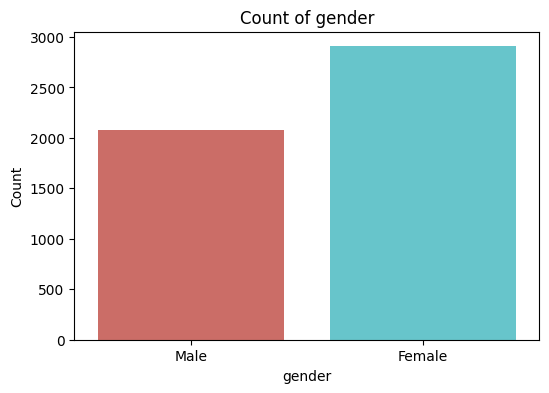

/tmp/ipykernel_14960/806768942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="hls")


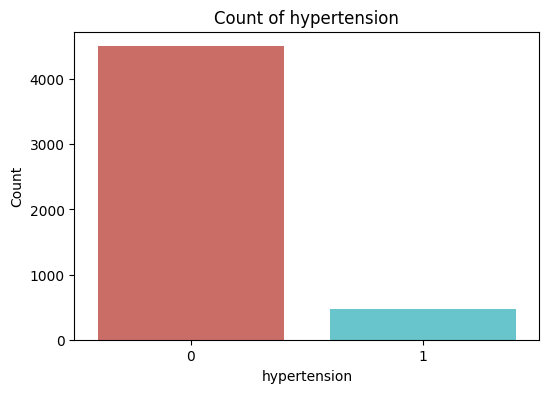

/tmp/ipykernel_14960/806768942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="hls")


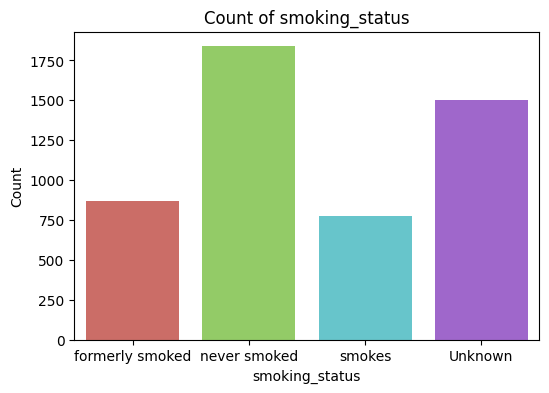

/tmp/ipykernel_14960/806768942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="hls")


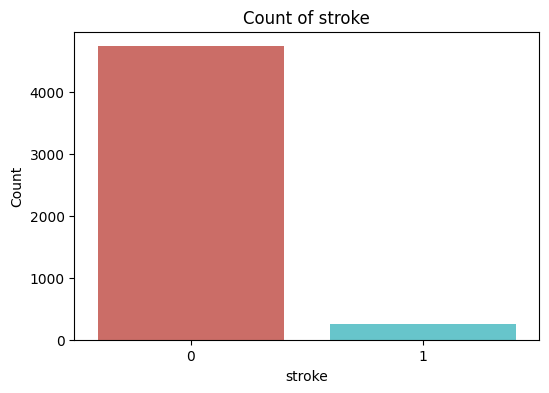

In [26]:
cols_to_plot = ["gender", "hypertension","smoking_status", "stroke"]

for col in cols_to_plot:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, palette="hls")
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

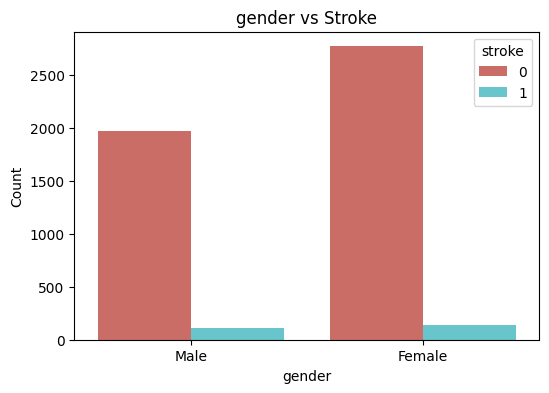

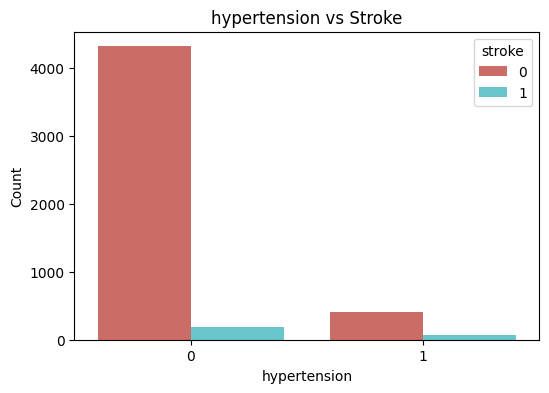

In [27]:
for col in ["gender", "hypertension"]:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="stroke", data=df, palette="hls")
    plt.title(f"{col} vs Stroke")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


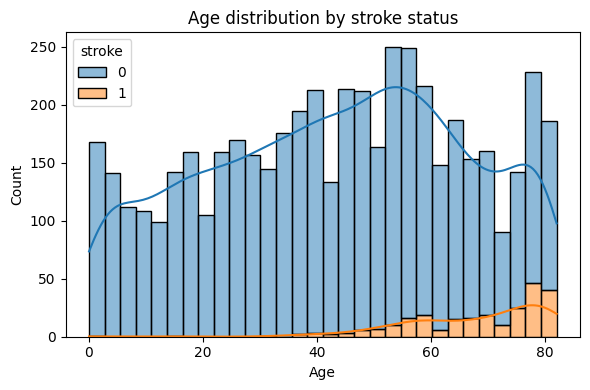

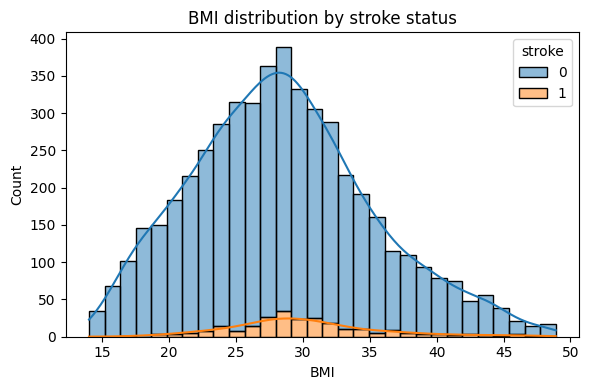

In [28]:
# Age vs Stroke
plt.figure(figsize=(6, 4))
sns.histplot(
    data=df,
    x="age",
    hue="stroke",
    bins=30,
    kde=True,
    multiple="stack"
)
plt.title("Age distribution by stroke status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# BMI vs stroke
plt.figure(figsize=(6, 4))
sns.histplot(
    data=df,
    x="bmi",
    hue="stroke",
    bins=30,
    kde=True,
    multiple="stack"
)
plt.title("BMI distribution by stroke status")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

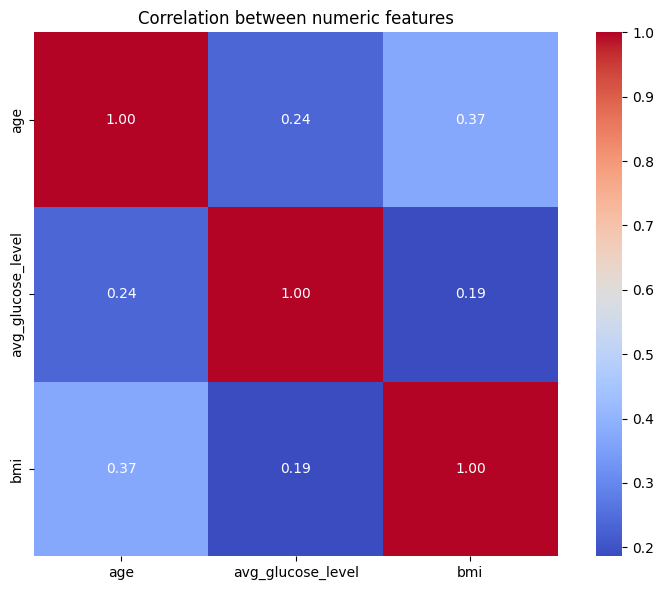

In [29]:

numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = [
    "gender", "hypertension", "heart_disease",
    "ever_married", "work_type", "Residence_type", "smoking_status"
]


corr = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

## Preprocessing Part

Before resampling:
Total samples: 4981
Stroke=0 (No Stroke): 4733
Stroke=1 (Stroke): 248

After resampling (Both Under & Over):
Total samples: 4000
Stroke=0 (No Stroke): 2000
Stroke=1 (Stroke): 2000


/tmp/ipykernel_14960/2655404286.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df_balanced, palette='hls')


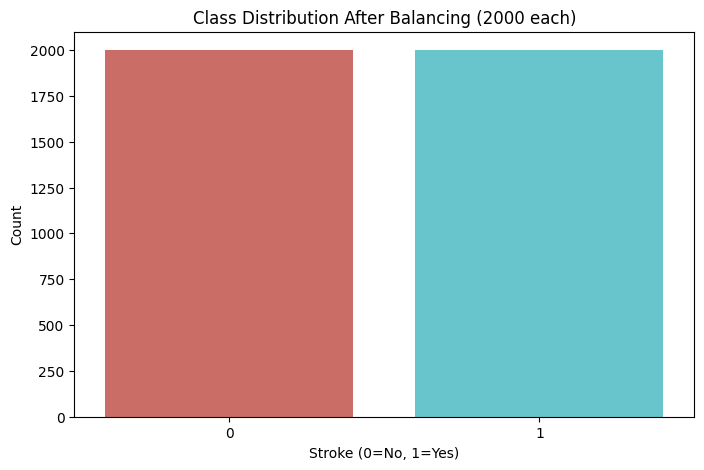

In [30]:
print("Before resampling:")
print(f"Total samples: {len(df)}")
print(f"Stroke=0 (No Stroke): {len(df[df['stroke']==0])}")
print(f"Stroke=1 (Stroke): {len(df[df['stroke']==1])}")

df_0 = df[df['stroke'] == 0]
df_1 = df[df['stroke'] == 1]

target_count = 2000

df_0_resampled = df_0.sample(n=target_count, replace=False, random_state=42)
df_1_resampled = df_1.sample(n=target_count, replace=True, random_state=42)

df_balanced = pd.concat([df_0_resampled, df_1_resampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter resampling (Both Under & Over):")
print(f"Total samples: {len(df_balanced)}")
print(f"Stroke=0 (No Stroke): {len(df_balanced[df_balanced['stroke']==0])}")
print(f"Stroke=1 (Stroke): {len(df_balanced[df_balanced['stroke']==1])}")

X = df_balanced.drop("stroke", axis=1)
y = df_balanced["stroke"]

plt.figure(figsize=(8, 5))
sns.countplot(x='stroke', data=df_balanced, palette='hls')
plt.title('Class Distribution After Balancing (2000 each)')
plt.xlabel('Stroke (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()


In [31]:
X["hypertension"] = X["hypertension"].astype(str)
X["heart_disease"] = X["heart_disease"].astype(str)


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Models

Logistic Regression
Accuracy: 0.79625
F1 score: 0.8029020556227328


<Figure size 400x400 with 0 Axes>

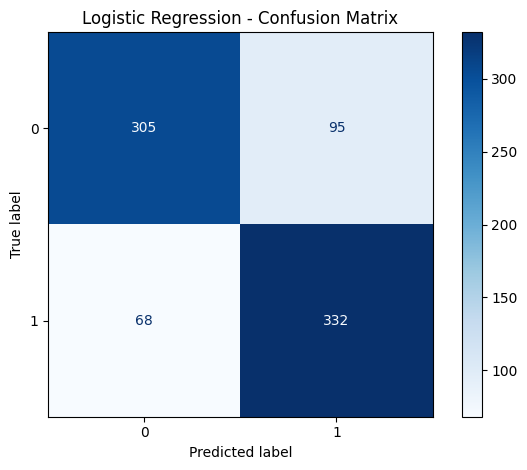

In [32]:
#logistic regression

log_reg = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

log_reg_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", log_reg),
])

log_reg_pipe.fit(X_train, y_train)

y_pred = log_reg_pipe.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

print("Logistic Regression")
print("Accuracy:", acc_lr)
print("F1 score:", f1_lr)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()



Random Forest
Accuracy: 0.9725
F1 score: 0.9732360097323601


<Figure size 400x400 with 0 Axes>

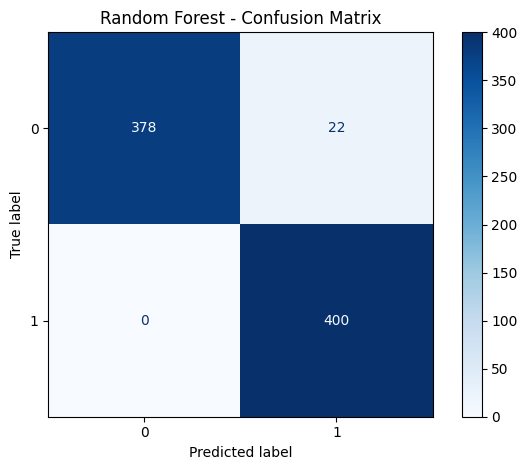

In [33]:
#random forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", rf_model),
])

rf_pipe.fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print("Random Forest")
print("Accuracy:", acc_rf)
print("F1 score:", f1_rf)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


Gradient Boosting
Accuracy: 0.85125
F1 score: 0.8601645123384254


<Figure size 400x400 with 0 Axes>

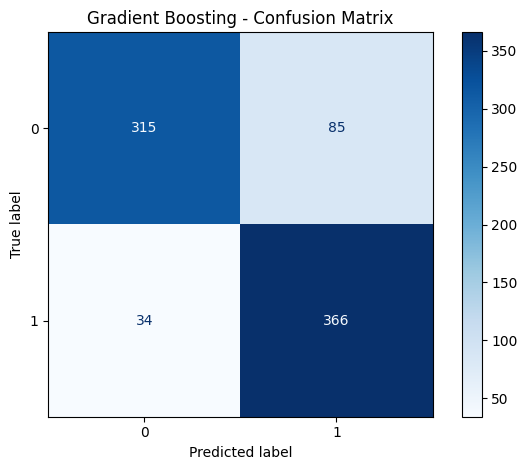

In [34]:
#gradient boosting
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", gb_model),
])

gb_pipe.fit(X_train, y_train)

y_pred = gb_pipe.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred)
f1_gb = f1_score(y_test, y_pred)

print("Gradient Boosting")
print("Accuracy:", acc_gb)
print("F1 score:", f1_gb)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

SVM
Accuracy: 0.845
F1 score: 0.8498789346246973


<Figure size 400x400 with 0 Axes>

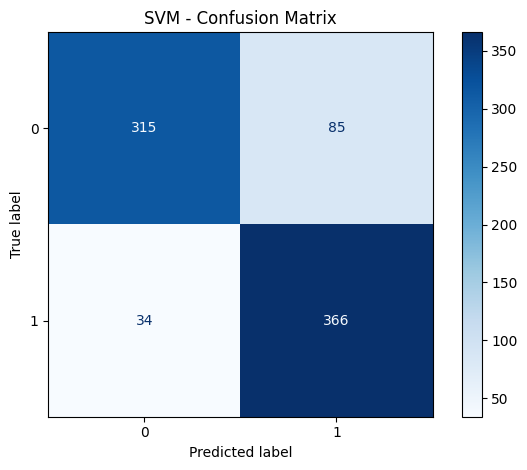

In [35]:
#svm

svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", svm_model),
])

svm_pipe.fit(X_train, y_train)

proba_svm = svm_pipe.predict_proba(X_test)[:, 1]
pred_svm = (proba_svm >= 0.5).astype(int)

acc_svm = accuracy_score(y_test, pred_svm)
f1_svm = f1_score(y_test, pred_svm)

print("SVM")
print("Accuracy:", acc_svm)
print("F1 score:", f1_svm)


#confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

KNN
Accuracy: 0.7925
F1 score: 0.8056206088992974
AUC: 0.874915625


<Figure size 400x400 with 0 Axes>

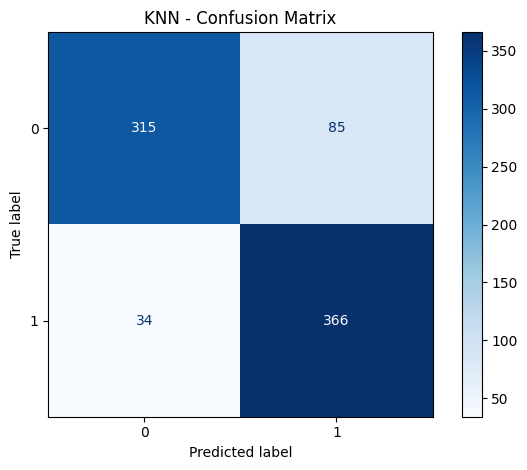

In [36]:
#knn

knn_model = KNeighborsClassifier(
    n_neighbors=15
)

knn_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", knn_model),
])

knn_pipe.fit(X_train, y_train)

proba_knn = knn_pipe.predict_proba(X_test)[:, 1]
pred_knn = (proba_knn >= 0.5).astype(int)

acc_knn = accuracy_score(y_test, pred_knn)
f1_knn = f1_score(y_test, pred_knn)
auc_knn = roc_auc_score(y_test, proba_knn)

print("KNN")
print("Accuracy:", acc_knn)
print("F1 score:", f1_knn)
print("AUC:", auc_knn)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

Result Comparison

In [37]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "SVM": SVC(
        kernel="rbf", probability=True,
        class_weight="balanced", random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15
    ),
}

metrics = {"Model": [], "Accuracy": [], "F1": []}

for name, base_model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", base_model),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy_score(y_test, pred)*100)
    metrics["F1"].append(f1_score(y_test, pred))

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

                 Model  Accuracy        F1
0  Logistic Regression    79.625  0.802902
1        Random Forest    97.250  0.973236
2    Gradient Boosting    85.125  0.860165
3                  SVM    84.500  0.849879
4                  KNN    79.250  0.805621


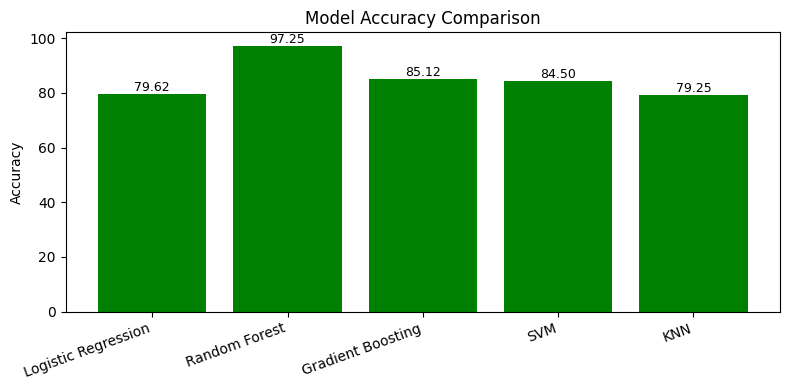

In [38]:
# Accuracy comparison graph


plt.figure(figsize=(8, 4))
bars = plt.bar(metrics_df["Model"], metrics_df["Accuracy"], color="green")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar, acc in zip(bars, metrics_df["Accuracy"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{acc:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


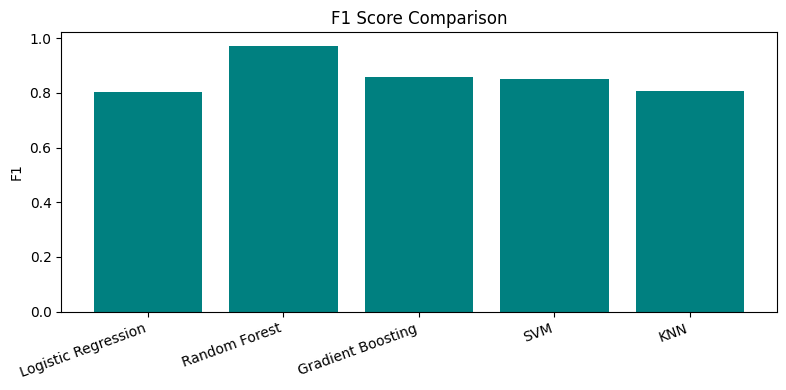

In [39]:
# F1 comparison graph

plt.figure(figsize=(8, 4))
plt.bar(metrics_df["Model"], metrics_df["F1"], color="teal")
plt.xticks(rotation=20, ha="right")
plt.ylabel("F1")
plt.title("F1 Score Comparison")
plt.tight_layout()
plt.show()
